In [7]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

import os



In [8]:
# load data
print(os.getcwd())
df = pd.read_csv('../data/music_features.csv')

/Users/brunoleitao/Documents/GitHub/brainplayback_task02/music_feature_extraction


In [9]:
df.head()

,lowlevel.average_loudness,lowlevel.barkbands_crest.mean,lowlevel.barkbands_crest.stdev,lowlevel.barkbands_flatness_db.mean,lowlevel.barkbands_flatness_db.stdev,lowlevel.barkbands_kurtosis.mean,lowlevel.barkbands_kurtosis.stdev,lowlevel.barkbands_skewness.mean,lowlevel.barkbands_skewness.stdev,lowlevel.barkbands_spread.mean,...,tonal.hpcp_entropy.mean,tonal.hpcp_entropy.stdev,tonal.key_edma.strength,tonal.key_krumhansl.strength,tonal.key_temperley.strength,tonal.tuning_diatonic_strength,tonal.tuning_equal_tempered_deviation,tonal.tuning_frequency,tonal.tuning_nontempered_energy_ratio,emotion
0,0.984629,9.366194,3.271858,0.146572,0.045194,4.056176,7.778135,1.504132,1.268401,18.078497,...,2.225347,0.688990,0.753155,0.752207,0.752781,0.644717,0.138863,440.000000,0.789783,Joyfulactivation
1,0.917135,9.215870,3.664309,0.101670,0.028441,2.215264,4.161178,1.347306,0.853917,25.441069,...,1.954790,0.695975,0.733425,0.735518,0.727721,0.639732,0.034799,439.745911,0.712456,Joyfulactivation
2,0.979716,14.814351,4.959631,0.224629,0.087561,28.017239,38.139870,3.634691,2.217910,12.920436,...,1.472135,0.790936,0.595217,0.596496,0.597491,0.479838,0.074582,439.745911,0.688742,Nostalgia
3,0.888772,13.000507,4.211658,0.282733,0.074104,12.859330,17.978224,1.671389,1.610298,6.656551,...,1.777743,0.757268,0.796125,0.809681,0.823362,0.750096,0.094925,436.960693,0.808362,Nostalgia
4,0.966672,11.821041,4.282730,0.201916,0.070722,12.231054,16.268501,2.405453,1.702980,11.617296,...,1.830180,0.616522,0.717120,0.719946,0.707451,0.445444,0.211904,434.193115,0.977908,Peacefulness


In [10]:
# principal component analysis
from sklearn.decomposition import PCA

In [11]:
# get 3 components
pca = PCA(n_components=3)
pca.fit(df.drop(columns=['emotion']))

pca.components_.shape

(3, 120)

Text(0.5, 0, 'Principal Component 1')

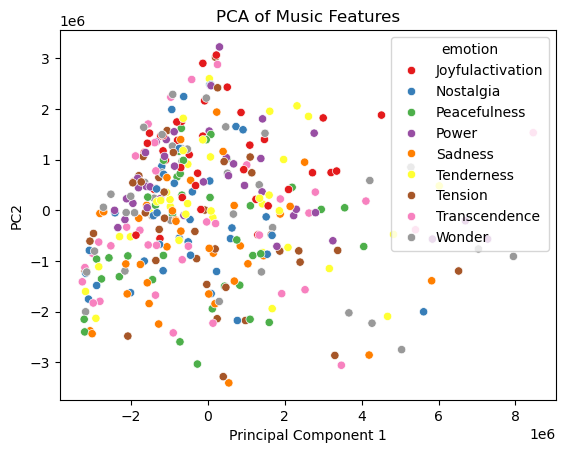

In [12]:
# plot the first two components using seaborn and emotion as hue
df_pca = pd.DataFrame(pca.transform(df.drop(columns=['emotion'])), columns=['PC1', 'PC2', 'PC3'])
df_pca['emotion'] = df['emotion']
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='emotion', palette='Set1')
plt.title('PCA of Music Features')
plt.xlabel('Principal Component 1')

# Classification of music emotion considering music features

In [13]:
# get values from df
X = df.drop(columns=['emotion']).values
y = df['emotion'].values
print(X.shape, y.shape)

(337, 120) (337,)


In [16]:
# transform y into a one-hot encoded matrix
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))
print(y_onehot.shape)

# transform y into an ordinal encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_ordinal = label_encoder.fit_transform(y)
print(y_ordinal.shape)


(337, 9)
(337,)


In [17]:
y_ordinal

array([0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1,
       2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3,
       4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 2, 2, 3, 3, 4, 5, 5, 6, 6,
       7, 7, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0,
       1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2,
       3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4,
       5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6,
       7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8,
       0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1,
       2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4,
       4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
       6, 7, 7, 8, 8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8,
       8, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 0, 0, 1,
       1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8,

In [ ]:
# classify using a simple SVM using the one-hot encoded y, sklearn SVC and 10 fold cross-validation  

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
svm = SVC(kernel='linear')
scores = cross_val_score(svm, X, y_ordinal, cv=10)
print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))
